In [ ]:
import refinitiv.data as rd
import pandas as pd
from datetime import date, timedelta, datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import pickle

In [294]:
key = 'afa544907ced4690b75ab2e31be66bc5af09caa9'
rd.open_session(app_key=key)

<refinitiv.data.session.Definition object at 0x224054e7c50 {name='workspace'}>

# Functions to gather data from Refinitiv

In [295]:
fields = [
    #EV
    'TR.F.ComShrOutsTot', 'TR.F.DebtLTTot', 'TR.F.STDebtCurrPortOfLTDebt', 'TR.F.PrefShHoldEq', 'TR.F.MinIntr', 'TR.F.CashCashEquivTot',
    #CFO and FCF
    'TR.F.NetCashFlowOp', 'TR.F.LeveredFOCF',
    #EBIT, revenue and eps
    'TR.F.EBIT', 'TR.F.TotRevenue', 'TR.F.EPSBasicExclExordItemsComTot',
    # equity, shares free float
    'TR.F.ComEqParentShHold'
    ]

def get_quarter_data(ticker, start_date, end_date):
    df = rd.get_history(
        universe=ticker,
        fields=fields,
        parameters={'Frq': 'FQ', 'Period': 'FQ0'},
        start = start_date,
        end=end_date,
    )
    df = df.apply(pd.to_numeric, errors='coerce')
    return df.fillna(0)

def get_daily_prices(ticker, start_date, end_date):
    df = rd.get_history(
    universe = ticker,
    fields = ['TR.PriceClose'],
    interval= '1D',
    start = start_date,
    end = end_date)

    return df.fillna(0)

def get_first_trade_and_sector(ticker):
    df = rd.get_data(
        universe=ticker,
        fields=["TR.FirstTradeDate",'TR.TRBCEconomicSector']
    )

    return df.fillna(0)

def get_free_float(ticker, start_date, end_date):
    df = rd.get_history(
        universe=ticker,
        fields= ['TR.SharesFreeFloat'],
        parameters={'Frq': 'FQ', 'Period': 'FQ0'},
        start = start_date,
        end=end_date,
    )
    df = df.apply(pd.to_numeric, errors='coerce')
    return df.fillna(0)

# Historical constituents by quarter of S&P 1500

I gather the historical constituents by each rebalancing period using Refinitiv API

In [482]:
const_2015to2025 = pd.read_csv(r"C:\Users\Ramon\Desktop\data laptop\QUANT PROJECTS\sp1500_constbyq_2014-2025.csv")
#const_2015to2025 = const_2015to2025.drop(columns=['Unnamed: 0'])
const_2015to2025

,asof_q_start,RIC
0,4/1/2014,AME.N
1,4/1/2014,CG.OQ
2,4/1/2014,AM.N
3,4/1/2014,ATGE.N
4,4/1/2014,ALKS.OQ
...,...,...
77027,1/1/2026,ALTR.OQ^C25
77028,1/1/2026,TDW.N
77029,1/1/2026,DELL.N
77030,1/1/2026,FTI.N


In [483]:
#convert to datetime
const_2015to2025['asof_q_start'] = pd.to_datetime(const_2015to2025['asof_q_start'])

#keep only q2 and q4
q2_q4_data_df = const_2015to2025[const_2015to2025['asof_q_start'].dt.quarter.isin([2, 4])] # extracts the calendar quarter and filters for q2 and q4
q2_q4_data_df

,asof_q_start,RIC
0,2014-04-01,AME.N
1,2014-04-01,CG.OQ
2,2014-04-01,AM.N
3,2014-04-01,ATGE.N
4,2014-04-01,ALKS.OQ
...,...,...
75499,2025-10-01,ALTR.OQ^C25
75500,2025-10-01,TDW.N
75501,2025-10-01,DELL.N
75502,2025-10-01,TTGT.OQ


In [484]:
# dictionary (keys as dates and values as the lists of active constituents)
const_by_q = (
    q2_q4_data_df
    .groupby('asof_q_start')['RIC'] # groups all rics by date
    .apply(list) # converts the rics to a list
    .to_dict() # converst all to dict, where the dates are keys
)

In [485]:
rebal_dates = list(const_by_q.keys())
rebal_dates

[Timestamp('2014-04-01 00:00:00'),
 Timestamp('2014-10-01 00:00:00'),
 Timestamp('2015-04-01 00:00:00'),
 Timestamp('2015-10-01 00:00:00'),
 Timestamp('2016-04-01 00:00:00'),
 Timestamp('2016-10-01 00:00:00'),
 Timestamp('2017-04-01 00:00:00'),
 Timestamp('2017-10-01 00:00:00'),
 Timestamp('2018-04-01 00:00:00'),
 Timestamp('2018-10-01 00:00:00'),
 Timestamp('2019-04-01 00:00:00'),
 Timestamp('2019-10-01 00:00:00'),
 Timestamp('2020-04-01 00:00:00'),
 Timestamp('2020-10-01 00:00:00'),
 Timestamp('2021-04-01 00:00:00'),
 Timestamp('2021-10-01 00:00:00'),
 Timestamp('2022-04-01 00:00:00'),
 Timestamp('2022-10-01 00:00:00'),
 Timestamp('2023-04-01 00:00:00'),
 Timestamp('2023-10-01 00:00:00'),
 Timestamp('2024-04-01 00:00:00'),
 Timestamp('2024-10-01 00:00:00'),
 Timestamp('2025-04-01 00:00:00'),
 Timestamp('2025-10-01 00:00:00')]

In [486]:
#starting at 2016
final_const_by_q = {}

cutoff = pd.Timestamp('2016-01-01')

for k, v in const_by_q.items():
    if k >= cutoff:
        final_const_by_q[k] = v

In [487]:
rebal_dates = list(final_const_by_q.keys())
rebal_dates

[Timestamp('2016-04-01 00:00:00'),
 Timestamp('2016-10-01 00:00:00'),
 Timestamp('2017-04-01 00:00:00'),
 Timestamp('2017-10-01 00:00:00'),
 Timestamp('2018-04-01 00:00:00'),
 Timestamp('2018-10-01 00:00:00'),
 Timestamp('2019-04-01 00:00:00'),
 Timestamp('2019-10-01 00:00:00'),
 Timestamp('2020-04-01 00:00:00'),
 Timestamp('2020-10-01 00:00:00'),
 Timestamp('2021-04-01 00:00:00'),
 Timestamp('2021-10-01 00:00:00'),
 Timestamp('2022-04-01 00:00:00'),
 Timestamp('2022-10-01 00:00:00'),
 Timestamp('2023-04-01 00:00:00'),
 Timestamp('2023-10-01 00:00:00'),
 Timestamp('2024-04-01 00:00:00'),
 Timestamp('2024-10-01 00:00:00'),
 Timestamp('2025-04-01 00:00:00'),
 Timestamp('2025-10-01 00:00:00')]

In [488]:
final_const_by_q

{Timestamp('2016-04-01 00:00:00'): ['AME.N',
  'CG.OQ',
  'AM.N',
  'ATGE.N',
  'ALKS.OQ',
  'NI.N',
  'CBU.N',
  'ANDE.OQ',
  'LIVN.OQ',
  'LUV.N',
  'IAC.OQ',
  'DAR.N',
  'FFIV.OQ',
  'PNW.N',
  'HL.N',
  'ADC.N',
  'AWR.N',
  'LH.N',
  'BMRN.OQ',
  'SLGN.N',
  'IART.OQ',
  'WAB.N',
  'KTOS.OQ',
  'AMP.N',
  'KKR.N',
  'EA.OQ',
  'OLN.N',
  'VRSK.OQ',
  'ZION.OQ',
  'APOG.OQ',
  'UCB.N',
  'MORN.OQ',
  'DHR.N',
  'CWK.N',
  'HSIC.OQ',
  'ALV.N',
  'WSR.N',
  'CNXC.OQ',
  'CARG.OQ',
  'INSP.N',
  'MLM.N',
  'XYL.N',
  'BG.N',
  'TPH.N',
  'TEX.N',
  'FDS.N',
  'PM.N',
  'ALGM.OQ',
  'ROL.N',
  'VLY.OQ',
  'VIR.OQ',
  'NVST.N',
  'NUE.N',
  'DORM.OQ',
  'ARW.N',
  'CSGS.OQ',
  'BCO.N',
  'GVA.N',
  'SCSC.OQ',
  'MZTI.OQ',
  'PLTR.OQ',
  'BIIB.OQ',
  'FFBC.OQ',
  'CRH.N',
  'HI.N',
  'COLL.OQ',
  'WOR.N',
  'AGCO.N',
  'HLIT.OQ',
  'VST.N',
  'HAL.N',
  'FIZZ.OQ',
  'NFG.N',
  'ABCB.N',
  'FBIN.N',
  'IBOC.OQ',
  'CENT.OQ',
  'WDAY.OQ',
  'SYF.N',
  'EMBC.OQ',
  'AR.N',
  'CME.OQ',
  '

In [489]:
# list of tickers
hist_const = set() #only unique values

for tickers in final_const_by_q.values():
    hist_const.update(tickers)

hist_const = list(hist_const)
hist_const

['WSR.N',
 'KNF.N',
 'BJ.N',
 'VOYA.N',
 'RYAM.N',
 'HOUS.N^A26',
 'GPI.N',
 'LTHM.N^A24',
 'NVST.N',
 'TNC.N',
 'SOLS.OQ',
 'VCYT.OQ',
 'ETR.N',
 'OVV.N',
 'TLMR.OQ^I16',
 'APVO.OQ',
 'ANGO.OQ',
 'ARCB.OQ',
 'GD.N',
 'ROIC.OQ^B25',
 'EXTN.N^J22',
 'FAST.OQ',
 'AZZ.N',
 'PGTI.N^C24',
 'JPM.N',
 'GOLF.N',
 'HCA.N',
 'CSR.N',
 'WGO.N',
 'UPS.N',
 'WLK.N',
 'CMA.N',
 'GAP.N',
 'HSKA.OQ^F23',
 'MODV.OQ^H25',
 'PRI.N',
 'OII.N',
 'OUT.N',
 'XHR.N',
 'HRMY.OQ',
 'TXNM.N',
 'RAVN.OQ^L21',
 'AEL.N^E24',
 'CAKE.OQ',
 'CROX.OQ',
 'VLY.OQ',
 'ICUI.OQ',
 'VNT.N',
 'ORLY.OQ',
 'TVRD.OQ',
 'YELP.N',
 'PANW.OQ',
 'THRY.OQ',
 'CVBF.OQ',
 'PSN.N',
 'PUMP.N',
 'VTOL.N',
 'CXW.N',
 'ROG.N',
 'GWRE.N',
 'SEDG.OQ',
 'MPWR.OQ',
 'CW.N',
 'GDEN.OQ',
 'TGT.N',
 'ASB.N',
 'VC.OQ',
 'AXTA.N',
 'RWT.N',
 'TRN.N',
 'NOW.N',
 'FUN.N',
 'FNBC.OQ^E17',
 'PTCT.OQ',
 'KRG.N',
 'SCHL.OQ',
 'ASRT.OQ',
 'TSCO.OQ',
 'CLDT.N',
 'KBR.N',
 'BEL.N^D19',
 'NDSN.OQ',
 'PJT.N',
 'SAIL.N^H22',
 'HTO.OQ',
 'TMHC.N',
 'AMZN.OQ',
 '

In [490]:
len(hist_const)

1797

Gather data of first trade day and sector. <br>
Then remove the tickers that are in Real Estate and Financials economic sectors. <br>
After removing those tickers, the next step is to gather fundamental data, daily price data and free float data.

In [ ]:
tickers_first_trade_and_sector = {}
error_tickers_first_trade_and_sector = []

for ticker in hist_const:
    try:
        tickers_first_trade_and_sector[ticker] = get_first_trade_and_sector(ticker)
    except Exception as e:
        error_tickers_first_trade_and_sector.append(ticker)
        print(f'Error with {ticker}: {e}')
        continue

In [17]:
# drop tickers that are in real estate and financials
univ_sectors = ['Industrials', 'Energy', 'Academic & Educational Services', 'Healthcare', 'Utilities',
                'Consumer Non-Cyclicals', 'Technology', 'Basic Materials', 'Consumer Cyclicals'] # exclude real estate and financials

for date, tickers in final_const_by_q.items():
    final_const_by_q[date] = [ticker for ticker in tickers
                              if tickers_first_trade_and_sector[ticker]['TRBC Economic Sector Name'].iloc[-1] in univ_sectors] 

In [18]:
print(error_tickers_first_trade_and_sector)

[]


In [19]:
# list of tickers
hist_const = set() #only unique values

for tickers in final_const_by_q.values():
    hist_const.update(tickers)

hist_const = list(hist_const)
print(len(hist_const))
hist_const

1386


['KNF.N',
 'BJ.N',
 'RYAM.N',
 'GPI.N',
 'LTHM.N^A24',
 'NVST.N',
 'TNC.N',
 'SOLS.OQ',
 'VCYT.OQ',
 'ETR.N',
 'OVV.N',
 'APVO.OQ',
 'ANGO.OQ',
 'ARCB.OQ',
 'GD.N',
 'EXTN.N^J22',
 'FAST.OQ',
 'AZZ.N',
 'PGTI.N^C24',
 'GOLF.N',
 'HCA.N',
 'WGO.N',
 'UPS.N',
 'WLK.N',
 'GAP.N',
 'HSKA.OQ^F23',
 'MODV.OQ^H25',
 'OII.N',
 'HRMY.OQ',
 'TXNM.N',
 'RAVN.OQ^L21',
 'CAKE.OQ',
 'CROX.OQ',
 'ICUI.OQ',
 'VNT.N',
 'ORLY.OQ',
 'TVRD.OQ',
 'YELP.N',
 'PANW.OQ',
 'THRY.OQ',
 'PSN.N',
 'PUMP.N',
 'VTOL.N',
 'CXW.N',
 'ROG.N',
 'GWRE.N',
 'SEDG.OQ',
 'MPWR.OQ',
 'CW.N',
 'GDEN.OQ',
 'TGT.N',
 'VC.OQ',
 'AXTA.N',
 'TRN.N',
 'NOW.N',
 'FUN.N',
 'PTCT.OQ',
 'SCHL.OQ',
 'ASRT.OQ',
 'TSCO.OQ',
 'KBR.N',
 'BEL.N^D19',
 'NDSN.OQ',
 'SAIL.N^H22',
 'HTO.OQ',
 'TMHC.N',
 'AMZN.OQ',
 'OAS.OQ^J20',
 'EBAY.OQ',
 'FRGI.OQ^J23',
 'MPAA.OQ',
 'CSL.N',
 'ROL.N',
 'EQT.N',
 'TTMI.OQ',
 'AVAV.OQ',
 'BAX.N',
 'CSCO.OQ',
 'TWNK.OQ^K23',
 'V.N',
 'CMC.N',
 'PHIN.N',
 'JYNT.OQ',
 'HUM.N',
 'YOU.N',
 'MLI.N',
 'DAR.N',
 'SLAB

In [ ]:
#store fundamental data for each ticker in a dictionary
#the keys for the dictionary are the tickers and the values the q_data_dfs with fundamental data
tickers_data = {}
error_tickers_fundamental = []

end_date = date.today()
start_date_fundamental = '2015-01-01' #end_date.replace(year=end_date.year - 11)

for ticker in hist_const:
    try:
        tickers_data[ticker] = get_quarter_data(ticker, start_date_fundamental, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers_fundamental.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

In [21]:
print(error_tickers_fundamental)

['OAS.OQ^J20', 'WW.OQ^E25', 'TLN.N^L16', 'EXPD.N', 'CRC.N^G20', 'MODG.N']


In [35]:
# run again to try to gather the data of error tickers
error_tickers = error_tickers_fundamental.copy()
error_tickers_fundamental = []

for ticker in error_tickers:
    try:
        tickers_data[ticker] = get_quarter_data(ticker, start_date_fundamental, end_date) #get raw data for each ticker
    except Exception as e:
        error_tickers_fundamental.append(ticker) #if i get an error fetching data the ticker is stored so i can evaluate later
        print(f"Error fetching {ticker}: {e}")
        continue #continue with the next ticker without interruption

Error fetching OAS.OQ^J20: Error code -1 | Unable to resolve all requested identifiers in ['OAS.OQ^J20'].
Error fetching WW.OQ^E25: Error code -1 | Unable to resolve all requested identifiers in ['WW.OQ^E25'].
Error fetching TLN.N^L16: Error code -1 | Unable to resolve all requested identifiers in ['TLN.N^L16'].
Error fetching CRC.N^G20: Error code -1 | Unable to resolve all requested identifiers in ['CRC.N^G20'].
Error fetching MODG.N: Error code -1 | Unable to resolve all requested identifiers in ['MODG.N'].


In [491]:
print(error_tickers_fundamental)

['OAS.OQ^J20', 'WW.OQ^E25', 'TLN.N^L16', 'CRC.N^G20', 'MODG.N']


In [607]:
tickers_data['EXPD.N'].head()

EXPD.N,Common Shares - Outstanding - Total,Debt - Long-Term - Total,Short-Term Debt & Current Portion of Long-Term Debt,Preferred Shareholders Equity,Minority Interest,Cash & Cash Equivalents - Total,Net Cash Flow from Operating Activities,Free Cash Flow,Earnings before Interest & Taxes (EBIT),Revenue from Business Activities - Total,"EPS - Basic - excl Extraordinary Items, Common - Total",Common Equity Attributable to Parent Shareholders,asof_date
Date,,,,,,,,,,,,,
2014-12-31,191655690,0,0,0,1359000,927107000,89532000,78710000,157871000,1768830000,0.51571,1868408000,2015-03-01
2015-03-31,191120214,0,0,0,628000,1033144000,134394000,124949000,168883000,1677526000,0.55683,1924891000,2015-05-30
2015-06-30,189117916,0,0,0,569000,985727000,181728000,168816000,182716000,1691553000,0.61758,1886621000,2015-08-29
2015-09-30,186183201,0,0,0,426000,968683000,132676000,123130000,191893000,1651332000,0.62789,1839045000,2015-11-29
2015-12-31,182067000,0,0,0,651000,807796000,115914000,103434000,177992000,1596221000,0.61842,1691993000,2016-02-29


In [ ]:
#store daily prices for each ticker in a dictionary
tickers_daily_prices = {}
error_tickers_daily_prices = []

start_date_prices = '2016-01-01'

for ticker in hist_const:
    try:
        tickers_daily_prices[ticker] = get_daily_prices(ticker, start_date_prices, end_date)
    except Exception as e:
        error_tickers_daily_prices.append(ticker)
        print(f'Error fetching {ticker}: {e}')
        continue

In [493]:
print(error_tickers_daily_prices)

[]


In [25]:
tickers_daily_prices['AAPL.OQ'].head()

AAPL.OQ,Price Close
Date,
2016-01-04,26.3375
2016-01-05,25.6775
2016-01-06,25.175
2016-01-07,24.1125
2016-01-08,24.24


In [26]:
tickers_free_float = {}
error_tickers_free_float = []

for ticker in hist_const:
    try:
        tickers_free_float[ticker] = get_free_float(ticker, start_date_fundamental, end_date)
    except Exception as e:
        error_tickers_free_float.append(ticker)
        print(f'Error with {ticker}: {e}')
        continue

In [27]:
print(error_tickers_free_float)

[]


In [38]:
tickers_free_float['META.OQ'].head()

META.OQ,Free Float
Date,
2015-03-31,2170727936
2015-06-30,2110890041
2015-09-30,2168328784
2015-12-31,2176599998
2016-03-31,2201060441


In [494]:
final_error_tickers = set(error_tickers_fundamental + error_tickers_first_trade_and_sector + error_tickers_free_float + error_tickers_daily_prices)
final_error_tickers

{'CRC.N^G20', 'MODG.N', 'OAS.OQ^J20', 'TLN.N^L16', 'WW.OQ^E25'}

In [40]:
with open('sp1500_fundamental_data_2015-2025', 'wb') as f:
    pickle.dump(tickers_data, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('sp1500_first_trade_sector_2015-2025', 'wb') as f:
    pickle.dump(tickers_first_trade_and_sector, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('sp1500_data_daily_prices_2016-2025', 'wb') as f:
    pickle.dump(tickers_daily_prices, f, protocol=pickle.HIGHEST_PROTOCOL)

with open('sp1500_data_free_float_2015-2025', 'wb') as f:
    pickle.dump(tickers_free_float, f, protocol=pickle.HIGHEST_PROTOCOL)

In [41]:
# drop error tickers
for date, tickers in final_const_by_q.items():
    final_const_by_q[date] = [ticker for ticker in tickers
                              if ticker not in final_error_tickers] # new list that contains every ticker in tickers only if the ticker isnt in final_error_tickers

In [439]:
# Data gather from S&P website
sp_1500_price_data_df = pd.read_excel(r"C:\Users\Ramon\Desktop\data laptop\QUANT PROJECTS\SP1500_2016-2026_daily.xls")
sp_1500_price_data_df = sp_1500_price_data_df.rename(columns={'Date': 'date', 'S&P Composite 1500': 'last_close'})
sp_1500_price_data_df = sp_1500_price_data_df.set_index('date')
sp_1500_price_data_df

,last_close
date,
2015-12-31,470.91
2016-01-04,463.63
2016-01-05,464.54
2016-01-06,458.44
2016-01-07,447.50
...,...
2026-01-16,1557.96
2026-01-20,1526.64
2026-01-21,1545.37


In [424]:
# Data gather from S&P website
sp1500_value_price_data_df = pd.read_excel(r"C:\Users\Ramon\Desktop\data laptop\QUANT PROJECTS\sp1500_value_2016-2026.xls")
sp1500_value_price_data_df = sp1500_value_price_data_df.rename(columns={'Effective date ': 'date', 'S&P Composite 1500 Value': 'last_close'})
sp1500_value_price_data_df = sp1500_value_price_data_df.set_index('date')
sp1500_value_price_data_df

,last_close
date,
2015-12-31,3168.91
2016-01-04,3128.88
2016-01-05,3136.21
2016-01-06,3086.45
2016-01-07,3016.83
...,...
2026-01-16,7732.59
2026-01-20,7607.39
2026-01-21,7717.56


In [425]:
# Data gather from MSCI website
msci_value_us_price_data_df = pd.read_excel(r"C:\Users\Ramon\Desktop\data laptop\QUANT PROJECTS\MSCI USA Value Index 1998-12-31 - 2026-01-23  - Daily.xlsx")
msci_value_us_price_data_df = msci_value_us_price_data_df.rename(columns={'Date': 'date', 'MSCI USA Value Index': 'price_close'})
msci_value_us_price_data_df = msci_value_us_price_data_df.set_index('date')
msci_value_us_price_data_df.index = pd.to_datetime(msci_value_us_price_data_df.index)
msci_value_us_price_data_df

,price_close
date,
1998-12-31,3199.097685
1999-01-01,3199.097685
1999-01-04,3200.432093
1999-01-05,3242.629279
1999-01-06,3321.420848
...,...
2026-01-19,16462.480767
2026-01-20,16212.117292
2026-01-21,16449.457500


# SEC Filling Deadlines

Form 10-Q shall be filled 40 days after the end of the fiscal quarter for large accelerated filers and accelerated filers. 45 days for all other registrants. <br>

Form 10-K shall be filled 60 days after the end of the fiscal year for large accelerated filers, 75 days for accelerated filers and 90 days for non accelerated filers.

# SEC Filer Status Categories

Large accelerated filers: have a public float of $700 million or more <br>
Accelerated filers: have a public float of $75 million or more, but less than $700 million <br>
Non-accelerated filers: are typically companies with public float of less than $75 million; are companies that are neither accelerated filers nor large accelerated filers


In [42]:
# ill add a lag of 60 days to the quarter data to avoid look-ahead bias. I believe its a conservative assumption
# robustness > precision

for ticker, q_data_df in tickers_data.items():
    # data is available as of this date
    q_data_df['asof_date'] = q_data_df.index + pd.Timedelta(days=60)  

In [608]:
tickers_data['AAPL.OQ'].tail()

AAPL.OQ,Common Shares - Outstanding - Total,Debt - Long-Term - Total,Short-Term Debt & Current Portion of Long-Term Debt,Preferred Shareholders Equity,Minority Interest,Cash & Cash Equivalents - Total,Net Cash Flow from Operating Activities,Free Cash Flow,Earnings before Interest & Taxes (EBIT),Revenue from Business Activities - Total,"EPS - Basic - excl Extraordinary Items, Common - Total",Common Equity Attributable to Parent Shareholders,asof_date
Date,,,,,,,,,,,,,
2024-09-28,15116786000,85750000000,20879000000,0.0,0.0,29943000000,26811000000,23903000000,29591000000,94930000000,1.64659,56950000000,2024-11-27
2024-12-28,15040731000,83956000000,12843000000,0.0,0.0,30299000000,29935000000,26995000000,42832000000,124300000000,2.40888,66758000000,2025-02-26
2025-03-29,14939315000,78566000000,19620000000,0.0,0.0,28162000000,23952000000,20881000000,29589000000,95359000000,1.65265,66796000000,2025-05-28
2025-06-28,14856722000,82430000000,19268000000,0.0,0.0,36269000000,27867000000,24405000000,28203000000,94036000000,1.57245,65830000000,2025-08-27
2025-09-27,14773260000,78328000000,20329000000,0.0,0.0,35934000000,29728000000,26486000000,32427000000,102466000000,1.82109,73733000000,2025-11-26


# Functions to calculate value signals

In [515]:
def get_market_cap(ticker, q_data_df, price_data_df):
    last_price = float(price_data_df['Price Close'].iloc[-1])
    shares = q_data_df['Common Shares - Outstanding - Total']
    
    market_cap = shares.iloc[-1] * last_price
    return market_cap

def enterprise_value(ticker, q_data_df, price_data_df):
    try:
        #q_data_df = tickers_data[ticker]
        last_price = float(price_data_df['Price Close'].iloc[-1])
        st_debt, lt_debt, shares = q_data_df['Short-Term Debt & Current Portion of Long-Term Debt'], q_data_df['Debt - Long-Term - Total'], q_data_df['Common Shares - Outstanding - Total']
        prefered, minority, cash = q_data_df['Preferred Shareholders Equity'], q_data_df['Minority Interest'], q_data_df['Cash & Cash Equivalents - Total']

        market_cap = shares.iloc[-1] * last_price
        total_debt = st_debt.iloc[-1] + lt_debt.iloc[-1]
        ev = market_cap + total_debt + prefered.iloc[-1] + minority.iloc[-1] - cash.iloc[-1]
        return ev
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def earnings_yield(ticker, q_data_df, price_data_df):
    try:
        #q_data_df = tickers_data[ticker]
        last_price = float(price_data_df['Price Close'].iloc[-1])
        eps = q_data_df['EPS - Basic - excl Extraordinary Items, Common - Total']
        e_y = eps.iloc[-4:].sum() / last_price
        return e_y
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def cfo_ev(ticker, q_data_df, price_data_df):
    try:
        #q_data_df = tickers_data[ticker]
        ev = enterprise_value(ticker, q_data_df, price_data_df)
        cfo = q_data_df['Net Cash Flow from Operating Activities']
        cfoev = cfo.iloc[-4:].sum() / ev
        return cfoev
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None
    
def bv_p(ticker, q_data_df, price_data_df):
    try:
        #q_data_df = tickers_data[ticker]
        last_price = float(price_data_df['Price Close'].iloc[-1])
        equity, shares = q_data_df['Common Equity Attributable to Parent Shareholders'], q_data_df['Common Shares - Outstanding - Total']
        bvps = equity.iloc[-1] / shares.iloc[-1]
        book_price = bvps / last_price
        return book_price
    except Exception as e:
        print(f'Error with {ticker}: {e}')
        return None

def sales_p(ticker, q_data_df, price_data_df):
    try:
        #q_data_df = tickers_data[ticker]
        last_price = float(price_data_df['Price Close'].iloc[-1])
        sales, shares = q_data_df['Revenue from Business Activities - Total'], q_data_df['Common Shares - Outstanding - Total']
        sps = sales.iloc[-4:].sum() / shares.iloc[-1]
        s_p = sps / last_price
        return s_p
    except Exception as e:
        print(f'Error with {ticker}: {e}')    
        return None

In [512]:
q_data_df_goog = tickers_data['GOOGL.OQ']
price_data_df_goog = tickers_daily_prices['GOOGL.OQ']
float(price_data_df_goog['Price Close'].iloc[-1])

327.93

In [517]:
print(get_market_cap('GOOGL.OQ', q_data_df_goog, price_data_df_goog))
print(enterprise_value('GOOGL.OQ', q_data_df_goog, price_data_df_goog))
print(earnings_yield('GOOGL.OQ', q_data_df_goog, price_data_df_goog))
print(cfo_ev('GOOGL.OQ', q_data_df_goog, price_data_df_goog))
print(bv_p('GOOGL.OQ', q_data_df_goog, price_data_df_goog))
print(sales_p('GOOGL.OQ', q_data_df_goog, price_data_df_goog))

3960410610000.0
3963310610000.0
0.031181105723782514
0.038206442769823684
0.09768355811974758
0.09733258441098863


# Calculate the value signals for all the tickers in each rebalancing period. 
What the code below is doing is calculating the value signals for each ticker during each rebalancing period, I'm creating a dictionary called "ratios_by_q" where I'm saving as key, the date of the rebalancing period and as values a dataframe with the tickers and the value signals (and other data required) calculated corresponding to that period.

In [ ]:
ratios_by_q = {}
errors = []  # optional: store errors for later review

for date in rebal_dates:
    date_as_datetime = pd.to_datetime(date)
    date_as_str = date.strftime('%Y-%m-%d')
    rows = []

    for ticker in final_const_by_q[date]:
        try:
            # the value metrics need at least 4 quarters of data (1 year)
            q_data_df = tickers_data[ticker].loc[tickers_data[ticker]['asof_date'] < date_as_datetime]
            n_rows = len(q_data_df)
            sector_ticker = tickers_first_trade_and_sector[ticker]['TRBC Economic Sector Name'].iloc[0]

            if n_rows >= 4: # 1 year of data is required (4 rows means at least 4 quarters of data)
                q_data_df = tickers_data[ticker].loc[tickers_data[ticker]["asof_date"] < date_as_datetime]
                price_data_df = tickers_daily_prices[ticker].loc[tickers_daily_prices[ticker].index < date_as_datetime] #the index are the dates
                free_float_data_df = tickers_free_float[ticker].loc[tickers_free_float[ticker].index < date_as_datetime]
                
                rows.append({
                    "ticker": ticker,
                    'economic_sector': tickers_first_trade_and_sector[ticker]['TRBC Economic Sector Name'].iloc[-1],
                    'last_price': price_data_df['Price Close'].iloc[-1],
                    'last_free_float': free_float_data_df['Free Float'].iloc[-1],
                    'market_cap': get_market_cap(ticker, q_data_df, price_data_df),
                    "earnings_yield": earnings_yield(ticker, q_data_df, price_data_df),
                    "cfo_ev": cfo_ev(ticker, q_data_df, price_data_df),
                    "bv_p": bv_p(ticker, q_data_df, price_data_df),
                    "sales_p": sales_p(ticker, q_data_df, price_data_df)
                })

        except Exception as e:
            errors.append({
                "date": date,
                "ticker": ticker,
                "error_type": type(e).__name__,
                "error": str(e)})
            continue

    ratios_by_q[date_as_str] = pd.DataFrame(rows)

errors_q_data_df = pd.DataFrame(errors)  # optional: inspect what failed

In [ ]:
errors_q_data_df

In [522]:
ratios_by_q

{'2016-04-01':            ticker                  economic_sector  last_price  \
 0           AME.N                      Industrials       49.98   
 1          ATGE.N  Academic & Educational Services       17.27   
 2         ALKS.OQ                       Healthcare       34.19   
 3            NI.N                        Utilities       23.56   
 4         ANDE.OQ           Consumer Non-Cyclicals       31.41   
 ...           ...                              ...         ...   
 1018    CXO.N^A21                           Energy      101.04   
 1019  AMAG.OQ^K20                       Healthcare       23.40   
 1020       VRA.OQ               Consumer Cyclicals       20.34   
 1021  NVTR.OQ^K19                       Healthcare        5.41   
 1022   DPLO.N^B20                       Healthcare       27.40   
 
       last_free_float    market_cap  earnings_yield    cfo_ev      bv_p  \
 0           230380929  1.177104e+10        0.049267  0.050460  0.276494   
 1            57528477  1.09

In [523]:
ratios_by_q['2019-10-01'].head(20)

,ticker,economic_sector,last_price,last_free_float,market_cap,earnings_yield,cfo_ev,bv_p,sales_p
0,AME.N,Industrials,91.820000,227190562,2.096671e+10,0.038588,0.043189,0.222580,0.240447
1,AM.N,Energy,7.400000,263572476,3.750668e+09,0.049026,0.048028,1.059107,0.082579
2,ATGE.N,Academic & Educational Services,38.090000,53882002,2.106491e+09,0.049314,0.102557,0.660591,0.481295
3,ALKS.OQ,Healthcare,19.510000,155570716,3.064960e+09,-0.059882,0.029559,0.356014,0.348277
4,NI.N,Utilities,29.920000,371914619,1.116762e+10,0.010178,0.030944,0.456337,0.468936
5,ANDE.OQ,Consumer Non-Cyclicals,22.430000,30995152,7.443171e+08,0.055927,-0.034237,1.303361,7.792477
6,LIVN.OQ,Healthcare,73.790000,48166564,3.570777e+09,-0.072665,0.014587,0.415408,0.307226
7,LUV.N,Industrials,54.010000,481849804,2.903130e+10,0.080030,0.145882,0.342389,0.769411
8,IAC.OQ,Technology,38.929377,77478858,3.279333e+09,0.100831,0.029810,0.909777,1.079061
9,DAR.N,Consumer Non-Cyclicals,19.130000,162726408,3.151649e+09,0.024471,0.089534,0.743392,1.055998


In [524]:
ratios_by_q['2018-04-01'].isna().sum()

ticker             0
economic_sector    0
last_price         0
last_free_float    0
market_cap         0
earnings_yield     0
cfo_ev             0
bv_p               1
sales_p            0
dtype: int64

For each rebalancing period and variable I calculated a Z-score and a composite Z-score that is equal to the equally weighted average of all variables. I'm also replacing infinites (in case they exist because of small values in data) to avoid errors when calculating standard deviation for z-scores

In [525]:
# cross sectional z scores
cols = ["earnings_yield", "cfo_ev", "bv_p", "sales_p"]

for date, ratios in ratios_by_q.items():
    ratios[cols] = ratios[cols].replace([np.inf, -np.inf], np.nan) #replace infinites with na to avoid breaking std and z score
    ratios['earnings_yield_z'] = (ratios['earnings_yield'] - ratios['earnings_yield'].mean()) / ratios['earnings_yield'].std()
    ratios['cfo_ev_z'] = (ratios['cfo_ev'] - ratios['cfo_ev'].mean()) / ratios['cfo_ev'].std()
    ratios['bv_p_z'] = (ratios['bv_p'] - ratios['bv_p'].mean()) / ratios['bv_p'].std()
    ratios['sales_p_z'] = (ratios['sales_p'] - ratios['sales_p'].mean()) / ratios['sales_p'].std()
    ratios['value_comp_z'] = (ratios['earnings_yield_z'] + ratios['cfo_ev_z'] + ratios['bv_p_z'] + ratios['sales_p_z']) / 4

ratios_by_q

{'2016-04-01':            ticker                  economic_sector  last_price  \
 0           AME.N                      Industrials       49.98   
 1          ATGE.N  Academic & Educational Services       17.27   
 2         ALKS.OQ                       Healthcare       34.19   
 3            NI.N                        Utilities       23.56   
 4         ANDE.OQ           Consumer Non-Cyclicals       31.41   
 ...           ...                              ...         ...   
 1018    CXO.N^A21                           Energy      101.04   
 1019  AMAG.OQ^K20                       Healthcare       23.40   
 1020       VRA.OQ               Consumer Cyclicals       20.34   
 1021  NVTR.OQ^K19                       Healthcare        5.41   
 1022   DPLO.N^B20                       Healthcare       27.40   
 
       last_free_float    market_cap  earnings_yield    cfo_ev      bv_p  \
 0           230380929  1.177104e+10        0.049267  0.050460  0.276494   
 1            57528477  1.09

In [526]:
ratios_by_q['2018-04-01']['earnings_yield'].std()

np.float64(1.5473769460745235)

In [527]:
ratios_by_q['2018-04-01'].dtypes

ticker               object
economic_sector      object
last_price          float64
last_free_float       int64
market_cap          float64
earnings_yield      float64
cfo_ev              float64
bv_p                float64
sales_p             float64
earnings_yield_z    float64
cfo_ev_z            float64
bv_p_z              float64
sales_p_z           float64
value_comp_z        float64
dtype: object

In [528]:
s = ratios_by_q["2018-04-01"]["earnings_yield"]

np.isinf(s).sum()

np.int64(0)

In [529]:
ratios_by_q['2018-04-01']

,ticker,economic_sector,last_price,last_free_float,market_cap,earnings_yield,cfo_ev,bv_p,sales_p,earnings_yield_z,cfo_ev_z,bv_p_z,sales_p_z,value_comp_z
0,AME.N,Industrials,75.97,227769522,1.756379e+10,0.033724,0.043645,0.229315,0.244832,-0.023318,-0.001582,-0.034654,-0.060968,-0.030131
1,ATGE.N,Academic & Educational Services,47.55,59374394,2.867027e+09,0.054320,0.074728,0.530152,0.399814,-0.010008,0.072623,-0.025261,-0.053952,-0.004150
2,ALKS.OQ,Healthcare,57.96,153826133,8.926388e+09,-0.015384,0.002128,0.134747,0.101203,-0.055054,-0.100696,-0.037607,-0.067469,-0.065207
3,NI.N,Utilities,23.91,336342980,8.058048e+09,0.036836,0.043579,0.536122,0.604936,-0.021307,-0.001740,-0.025074,-0.044668,-0.023197
4,ANDE.OQ,Consumer Non-Cyclicals,33.10,27005944,9.389477e+08,-0.033155,0.053829,0.868208,3.926039,-0.066539,0.022730,-0.014705,0.105662,0.011787
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,CUTR.OQ^C25,Healthcare,50.25,13197688,6.772681e+08,0.053832,0.021546,0.095816,0.223682,-0.010323,-0.054339,-0.038823,-0.061925,-0.041352
1096,TVPT.N^E19,Technology,16.34,124331761,2.048164e+09,0.080871,0.076454,-0.098772,1.194865,0.007151,0.076745,-0.044899,-0.017965,0.005258
1097,REI.A,Energy,14.35,56292426,7.781148e+08,0.011701,0.056095,0.458291,0.085720,-0.037551,0.028139,-0.027504,-0.068170,-0.026271
1098,FNSR.OQ^I19,Technology,15.81,113976472,1.809613e+09,0.080664,0.084032,0.906500,0.753720,0.007017,0.094834,-0.013509,-0.037933,0.012602


In [530]:
ratios_by_q['2025-04-01'].isna().sum()

ticker              0
economic_sector     0
last_price          0
last_free_float     0
market_cap          0
earnings_yield      0
cfo_ev              0
bv_p                1
sales_p             1
earnings_yield_z    0
cfo_ev_z            0
bv_p_z              1
sales_p_z           1
value_comp_z        1
dtype: int64

In [531]:
sectors = list(ratios_by_q['2025-04-01']['economic_sector'].unique())
sectors

['Industrials',
 'Energy',
 'Academic & Educational Services',
 'Healthcare',
 'Utilities',
 'Consumer Non-Cyclicals',
 'Technology',
 'Basic Materials',
 'Consumer Cyclicals']

I'm computing a sector relative value Z-score by looping through the dictionary with keys as dates and values as DFs. I'm using groupby() to group each group of value signals by economic sector and then standardizing the composite Z-score by sectors (by standardizing, I mean, I'm grouping all value composite Z-scores by sector and then calculating Z-scores again but for each sector). After that I'm winsorizing sector Z-scores by capping values below 1st percentile and above 99th percentile.

In [532]:
# sector relative value z scores
for date, ratios in ratios_by_q.items():
    ratios['value_comp_sector_z'] = (ratios.groupby('economic_sector') #group by economic sector
                                     ['value_comp_z'] #value_comp_z per sector
                                     .transform(lambda s: (s - s.mean()) / s.std())) #transform returns one value per og row
    #winsorize
    ratios['value_comp_sector_z'] = ratios['value_comp_sector_z'].clip(lower=ratios['value_comp_sector_z'].quantile(.01),
                                                                       upper=ratios['value_comp_sector_z'].quantile(.99))

In [533]:
ratios_by_q['2018-04-01']

,ticker,economic_sector,last_price,last_free_float,market_cap,earnings_yield,cfo_ev,bv_p,sales_p,earnings_yield_z,cfo_ev_z,bv_p_z,sales_p_z,value_comp_z,value_comp_sector_z
0,AME.N,Industrials,75.97,227769522,1.756379e+10,0.033724,0.043645,0.229315,0.244832,-0.023318,-0.001582,-0.034654,-0.060968,-0.030131,-0.528961
1,ATGE.N,Academic & Educational Services,47.55,59374394,2.867027e+09,0.054320,0.074728,0.530152,0.399814,-0.010008,0.072623,-0.025261,-0.053952,-0.004150,0.028197
2,ALKS.OQ,Healthcare,57.96,153826133,8.926388e+09,-0.015384,0.002128,0.134747,0.101203,-0.055054,-0.100696,-0.037607,-0.067469,-0.065207,-0.242942
3,NI.N,Utilities,23.91,336342980,8.058048e+09,0.036836,0.043579,0.536122,0.604936,-0.021307,-0.001740,-0.025074,-0.044668,-0.023197,-1.064965
4,ANDE.OQ,Consumer Non-Cyclicals,33.10,27005944,9.389477e+08,-0.033155,0.053829,0.868208,3.926039,-0.066539,0.022730,-0.014705,0.105662,0.011787,-0.104962
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,CUTR.OQ^C25,Healthcare,50.25,13197688,6.772681e+08,0.053832,0.021546,0.095816,0.223682,-0.010323,-0.054339,-0.038823,-0.061925,-0.041352,0.000917
1096,TVPT.N^E19,Technology,16.34,124331761,2.048164e+09,0.080871,0.076454,-0.098772,1.194865,0.007151,0.076745,-0.044899,-0.017965,0.005258,0.113313
1097,REI.A,Energy,14.35,56292426,7.781148e+08,0.011701,0.056095,0.458291,0.085720,-0.037551,0.028139,-0.027504,-0.068170,-0.026271,-0.662872
1098,FNSR.OQ^I19,Technology,15.81,113976472,1.809613e+09,0.080664,0.084032,0.906500,0.753720,0.007017,0.094834,-0.013509,-0.037933,0.012602,0.126170


The final value score is calculated following this logic: <br>
• If sector-z  > 0, FVS = 1 + sector-z <br>
• If sector-z = 0, FVS = 1 <br>
• If sector-z < 0, FVS = (1 – sector-z)^-1 <br> 


In [534]:
# final value score
for date, ratios in ratios_by_q.items():
    z = ratios['value_comp_sector_z']
    
    ratios['FVS'] = np.where(z > 0, # when z is more than 0, then FVS is 1 + z
                             1 + z, 
                             np.where(z < 0, (1 - z) ** -1, # when z is less than 0, FVS is (1 - z) ** -1
                                      0)) # else is 0
    
# np.where(condition, value_if_true, value_if_false)
# vectorized if-else and works element by element
# for every row, if the condition is true, take this value otherwise take that value

In [535]:
ratios_by_q['2024-04-01']

,ticker,economic_sector,last_price,last_free_float,market_cap,earnings_yield,cfo_ev,bv_p,sales_p,earnings_yield_z,cfo_ev_z,bv_p_z,sales_p_z,value_comp_z,value_comp_sector_z,FVS
0,AME.N,Industrials,182.900000,230088270,4.223711e+10,0.031145,0.038442,0.206695,0.156188,-0.027507,-0.435994,-0.034998,-0.071244,-0.142436,-0.629129,0.613825
1,AM.N,Energy,14.060000,338007068,6.744765e+09,0.055078,0.078236,0.319022,0.154456,-0.022255,0.136593,-0.030793,-0.071343,0.003051,-0.686328,0.593004
2,ATGE.N,Academic & Educational Services,51.400000,38229326,2.031636e+09,0.055542,0.092633,0.674037,0.736259,-0.022153,0.343754,-0.017501,-0.037951,0.066537,0.770828,1.770828
3,ALKS.OQ,Healthcare,27.070000,166593972,4.520144e+09,0.140737,0.092193,0.266072,0.367998,-0.003457,0.337425,-0.032775,-0.059087,0.060526,0.532988,1.532988
4,NI.N,Utilities,27.660000,447466985,1.237458e+10,0.057326,0.078351,0.628991,0.444896,-0.021761,0.138262,-0.019188,-0.054673,0.010660,0.282763,1.282763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1197,CRK.N,Energy,9.280000,90052367,2.583825e+09,0.082233,0.195235,0.912761,0.605733,-0.016296,1.820088,-0.008564,-0.045442,0.437447,0.521855,1.521855
1198,BERY.N^D25,Basic Materials,55.522092,115489147,6.440563e+09,0.086343,0.112471,0.516725,1.853410,-0.015394,0.629205,-0.023391,0.026168,0.154147,0.441736,1.441736
1199,PINC.OQ^K25,Healthcare,22.100000,103794304,2.647944e+09,0.062651,0.093059,0.902666,0.366599,-0.020593,0.349890,-0.008942,-0.059167,0.065297,0.545620,1.545620
1200,ALTM.N^C25,Basic Materials,4.310000,1073044084,7.752918e+08,0.263831,0.354058,2.301327,1.138281,0.023556,4.105393,0.043422,-0.014877,1.039374,3.017500,4.017500


I'm selecting the stocks that are at or above the 70th percentile for the FVS

In [ ]:
# security selection
selected_stocks = {}

for date, ratios in ratios_by_q.items():
    cutoff = ratios['FVS'].quantile(.7) # securities with FVS at or above the 70th percentile 
    sel_stocks = ratios[ratios['FVS'] >= cutoff]
    selected_stocks[date] = sel_stocks

selected_stocks

{'2016-04-01':            ticker economic_sector  last_price  last_free_float    market_cap  \
 3            NI.N       Utilities   23.560000        317642684  7.518234e+09   
 5           LUV.N     Industrials   44.800000        638027972  3.026661e+10   
 6          IAC.OQ      Technology    8.408474         76504318  6.981994e+08   
 8         FFIV.OQ      Technology  105.850000         66827139  7.277293e+09   
 12           LH.N      Healthcare  100.623220        100903574  1.019313e+10   
 ...           ...             ...         ...              ...           ...   
 1005   FLOW.N^D22     Industrials   25.080000         40155570  1.037979e+09   
 1008   EXTN.N^J22          Energy   15.460000         31210343  5.433816e+08   
 1015  CRAY.OQ^I19      Technology   41.910000         39430620  1.705473e+09   
 1017  SCAI.OQ^C17      Healthcare   46.280000         39294468  1.836853e+09   
 1019  AMAG.OQ^K20      Healthcare   23.400000         34395795  8.127549e+08   
 
       earni

In [559]:
selected_stocks['2018-04-01']

,ticker,economic_sector,last_price,last_free_float,market_cap,earnings_yield,cfo_ev,bv_p,sales_p,earnings_yield_z,cfo_ev_z,bv_p_z,sales_p_z,value_comp_z,value_comp_sector_z,FVS
6,LUV.N,Industrials,57.280000,580941851,3.371219e+10,0.060709,0.109257,0.285980,0.627251,-0.005879,0.155056,-0.032885,-0.043658,0.018159,1.172838,2.172838
7,IAC.OQ,Technology,27.929421,49425787,2.307473e+09,0.163172,0.156629,1.053112,1.433273,0.060338,0.268147,-0.008931,-0.007173,0.078095,0.240828,1.240828
10,PNW.N,Utilities,79.800000,111482153,8.917786e+09,0.055784,0.080574,0.561427,0.399662,-0.009062,0.086580,-0.024284,-0.053959,-0.000181,0.202673,1.202673
13,LH.N,Healthcare,138.955058,101352438,1.415952e+10,0.049776,0.072697,0.480532,0.727991,-0.012945,0.067775,-0.026810,-0.039098,-0.002769,0.395347,1.395347
19,OLN.N,Basic Materials,30.390000,165378743,5.078169e+09,0.022062,0.076584,0.542262,1.234382,-0.030855,0.077054,-0.024882,-0.016176,0.001285,0.243414,1.243414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1079,DBI.N,Consumer Cyclicals,22.460000,64062554,1.796530e+09,0.047689,0.146154,0.527996,1.540477,-0.014293,0.243142,-0.025328,-0.002320,0.050300,1.126721,2.126721
1080,MIK.OQ^D21,Consumer Cyclicals,19.710000,128674398,3.572694e+09,0.099942,0.085586,-0.485023,1.461700,0.019475,0.098545,-0.056959,-0.005886,0.013794,0.320508,1.320508
1084,AAOI.OQ,Technology,25.060000,18456351,4.874421e+08,0.144663,0.185636,0.683724,0.784358,0.048377,0.337397,-0.020465,-0.036546,0.082191,0.247998,1.247998
1086,MDR.N^A20,Energy,18.270000,281706696,1.729723e+09,0.105148,0.072451,1.017889,1.725959,0.022840,0.067186,-0.010031,0.006075,0.021518,0.351168,1.351168


In [ ]:
# weigthing scheme
for date, stocks in selected_stocks.items():
    stocks['free_float_marketcap'] = stocks['last_free_float'] * stocks['last_price']
    stocks['prelim_weight'] = stocks['free_float_marketcap'] * stocks['FVS']
    total_prelim_weight = stocks['prelim_weight'].sum() 
    stocks['final_weight'] = stocks['prelim_weight'] / total_prelim_weight

In [561]:
selected_stocks['2016-04-01'].sort_values(by='FVS')

,ticker,economic_sector,last_price,last_free_float,market_cap,earnings_yield,cfo_ev,bv_p,sales_p,earnings_yield_z,cfo_ev_z,bv_p_z,sales_p_z,value_comp_z,value_comp_sector_z,FVS,free_float_marketcap,prelim_weight,final_weight
513,DLB.N,Technology,43.460000,49103764,4.379496e+09,0.038538,0.095419,0.411804,0.223134,-0.016027,0.230152,-0.031804,-0.060712,0.030402,0.241728,1.241728,2.134050e+09,2.649908e+09,0.000349
171,XNCR.OQ,Healthcare,13.420000,30233859,5.441949e+08,-0.034574,0.050161,0.298481,0.051015,-0.038440,-0.211391,-0.035112,-0.066824,-0.087942,0.241802,1.241802,4.057384e+08,5.038467e+08,0.000066
718,PLNT.N,Consumer Cyclicals,14.277932,36597985,5.225438e+08,0.013138,0.082426,-0.029433,0.632554,-0.023813,0.103387,-0.044684,-0.046172,-0.002820,0.245898,1.245898,5.225435e+08,6.510358e+08,0.000086
382,BC.N,Consumer Cyclicals,47.980000,90011681,4.357208e+09,0.051601,0.079669,0.294064,0.867574,-0.012022,0.076494,-0.035241,-0.037825,-0.002148,0.250676,1.250676,4.318760e+09,5.401369e+09,0.000712
626,AVNS.N,Healthcare,28.730000,46362434,1.339247e+09,-0.318380,0.054591,0.787980,1.175586,-0.125446,-0.168176,-0.020823,-0.026886,-0.085333,0.252378,1.252378,1.331993e+09,1.668158e+09,0.000220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889,MU.OQ,Technology,10.470000,1032606207,1.083645e+10,0.188056,0.302611,1.135150,1.381356,0.029810,2.251570,-0.010689,-0.019578,0.562778,3.149088,4.149088,1.081139e+10,4.485740e+10,0.005915
897,BRKb.N,Consumer Non-Cyclicals,141.880000,1251571783,2.331646e+08,103.298853,2.448534,1096.006861,900.518351,31.640036,23.187707,31.949013,31.912584,29.672335,3.149088,4.149088,1.775730e+11,7.367661e+11,0.097159
71,ARCB.OQ,Industrials,21.590000,24164682,5.582771e+08,0.079105,0.246167,1.054544,4.777028,-0.003590,1.700884,-0.013042,0.101016,0.446317,3.149088,4.149088,5.217155e+08,2.164644e+09,0.000285
59,MOH.N,Healthcare,64.490000,42908533,3.611440e+09,0.045307,0.389079,0.431130,3.925858,-0.013952,3.095176,-0.031240,0.070788,0.780193,3.149088,4.149088,2.767171e+09,1.148124e+10,0.001514


In [ ]:
# calculate daily returns of stocks
for ticker, prices in tickers_daily_prices.items():
    prices = prices.sort_index()
    prices['daily_return'] = prices['Price Close'].pct_change()
    prices['daily_return'].replace([np.inf, -np.inf], np.nan, inplace=True)
    tickers_daily_prices[ticker] = prices

In [609]:
tickers_daily_prices

{'KNF.N': KNF.N       Price Close  daily_return
 Date                                 
 2023-05-25         39.4          <NA>
 2023-05-26        37.68     -0.043655
 2023-05-30        35.51      -0.05759
 2023-05-31        36.65      0.032104
 2023-06-01        35.02     -0.044475
 ...                 ...           ...
 2026-01-16        83.33      0.038509
 2026-01-20        76.97     -0.076323
 2026-01-21        80.32      0.043523
 2026-01-22        75.95     -0.054407
 2026-01-23        73.46     -0.032785
 
 [668 rows x 2 columns],
 'BJ.N': BJ.N        Price Close  daily_return
 Date                                 
 2018-06-28         22.0          <NA>
 2018-06-29        23.65         0.075
 2018-07-02        23.53     -0.005074
 2018-07-03        24.91      0.058649
 2018-07-05        23.75     -0.046568
 ...                 ...           ...
 2026-01-16         93.4      -0.01591
 2026-01-20        92.17     -0.013169
 2026-01-21        94.65      0.026907
 2026-01-22         

In [542]:
today = pd.Timestamp.today().normalize()
rebal_dates.append(today)
rebal_dates

[Timestamp('2016-04-01 00:00:00'),
 Timestamp('2016-10-01 00:00:00'),
 Timestamp('2017-04-01 00:00:00'),
 Timestamp('2017-10-01 00:00:00'),
 Timestamp('2018-04-01 00:00:00'),
 Timestamp('2018-10-01 00:00:00'),
 Timestamp('2019-04-01 00:00:00'),
 Timestamp('2019-10-01 00:00:00'),
 Timestamp('2020-04-01 00:00:00'),
 Timestamp('2020-10-01 00:00:00'),
 Timestamp('2021-04-01 00:00:00'),
 Timestamp('2021-10-01 00:00:00'),
 Timestamp('2022-04-01 00:00:00'),
 Timestamp('2022-10-01 00:00:00'),
 Timestamp('2023-04-01 00:00:00'),
 Timestamp('2023-10-01 00:00:00'),
 Timestamp('2024-04-01 00:00:00'),
 Timestamp('2024-10-01 00:00:00'),
 Timestamp('2025-04-01 00:00:00'),
 Timestamp('2025-10-01 00:00:00'),
 Timestamp('2026-01-24 00:00:00')]

In [543]:
tickers_daily_prices['AAPL.OQ']

AAPL.OQ,Price Close,daily_return
Date,,
2016-01-04,26.3375,<NA>
2016-01-05,25.6775,-0.025059
2016-01-06,25.175,-0.01957
2016-01-07,24.1125,-0.042205
2016-01-08,24.24,0.005288
...,...,...
2026-01-16,255.53,-0.010379
2026-01-20,246.7,-0.034556
2026-01-21,247.65,0.003851


# Backtest of the US Value Select

I created a dictionary called "daily_const_returns", where I'm storing as keys, the dates and as DataFrames as values, these DFs contain the last close of the ticker, the weight of the ticker at open and close, the daily return and the weighted return. I'm looping through the rebalancing dates and the last date available at the moment (which is the day where the backtest end). I'm using the dates of the daily returns of AAPL, because that ticker has been active for the whole duration of the backtest, I'm using those dates to loop trough them and calculate the daily returns and weights of each ticker. The constituents' weights for rebalancing dates is as was explained before, for the rest of dates is calculated according to the up or downs of each ticker and then standardize to ensure that the sum of the weights is 1.

In [562]:
daily_const_returns = {}
error_tickers_backtest = set()

for start, end in zip(rebal_dates, rebal_dates[1:]):
    # this stock has been trading for the whole backtest period
    dates = tickers_daily_prices['AAPL.OQ'].loc[
        (tickers_daily_prices['AAPL.OQ'].index >= start) & (tickers_daily_prices['AAPL.OQ'].index < end)].index.tolist()

    rebal_trading_day = dates[0]
    start_str = start.strftime('%Y-%m-%d')
    tickers = list(selected_stocks[start_str]['ticker'])

    date_progress = []

    for date in dates: # because im using the dates of tickers_daily_prices im starting before
        date_str = date.strftime('%Y-%m-%d')
        rows = []
        for ticker in tickers:
            try:
                # if date not in index, use 0, that means that the stock got delisted between rebalancing periods
                price = tickers_daily_prices[ticker]['Price Close'].get(date, 0) #loops up date, if found returns value if not returns 0
                daily_ret = tickers_daily_prices[ticker]['daily_return'].get(date, 0) #loops up date, if found returns value if not returns 0
                
                # if current date equals the date of rebalance then the constituent weight is the one defined above with the rules for weights
                if date == rebal_trading_day:
                    const_weight_open = selected_stocks[start_str].loc[selected_stocks[start_str]['ticker'] == ticker, 'final_weight'].item() #returns one value instead of pandas series
                # if the current date is not the rebalance date, then the weight will drift from target weights and its calculated 
                else:
                    const_weight_open = daily_const_returns[date_progress[-1]].at[ticker, 'const_weight_close']

                rows.append({
                    'ticker': ticker,
                    'last_close': price,
                    'const_weight_open': const_weight_open,
                    'daily_return': daily_ret,
                    'weighted_return': daily_ret * const_weight_open,
                    'const_weight_close': const_weight_open * (1 + daily_ret),
                })

            except Exception as e:
                error_tickers_backtest.add(ticker)
                print(f'Error with {ticker}: {e}')
        
        daily_const_returns[date_str] = pd.DataFrame(rows).set_index('ticker') #using ticker as index is faster
        
        new_port_weight = daily_const_returns[date_str]['const_weight_close'].sum()
        daily_const_returns[date_str]['const_weight_close'] = daily_const_returns[date_str]['const_weight_close'] / new_port_weight

        date_progress.append(date_str)

In [563]:
print(len(daily_const_returns.keys()))
daily_const_returns.keys()

2468


dict_keys(['2016-04-01', '2016-04-04', '2016-04-05', '2016-04-06', '2016-04-07', '2016-04-08', '2016-04-11', '2016-04-12', '2016-04-13', '2016-04-14', '2016-04-15', '2016-04-18', '2016-04-19', '2016-04-20', '2016-04-21', '2016-04-22', '2016-04-25', '2016-04-26', '2016-04-27', '2016-04-28', '2016-04-29', '2016-05-02', '2016-05-03', '2016-05-04', '2016-05-05', '2016-05-06', '2016-05-09', '2016-05-10', '2016-05-11', '2016-05-12', '2016-05-13', '2016-05-16', '2016-05-17', '2016-05-18', '2016-05-19', '2016-05-20', '2016-05-23', '2016-05-24', '2016-05-25', '2016-05-26', '2016-05-27', '2016-05-31', '2016-06-01', '2016-06-02', '2016-06-03', '2016-06-06', '2016-06-07', '2016-06-08', '2016-06-09', '2016-06-10', '2016-06-13', '2016-06-14', '2016-06-15', '2016-06-16', '2016-06-17', '2016-06-20', '2016-06-21', '2016-06-22', '2016-06-23', '2016-06-24', '2016-06-27', '2016-06-28', '2016-06-29', '2016-06-30', '2016-07-01', '2016-07-05', '2016-07-06', '2016-07-07', '2016-07-08', '2016-07-11', '2016-07-

In [612]:
daily_const_returns['2020-11-05']

,last_close,const_weight_open,daily_return,weighted_return,const_weight_close
ticker,,,,,
AM.N,5.790000,0.000136,0.028419,3.869903e-06,0.000138
ATGE.N,24.180000,0.000198,-0.036653,-7.255815e-06,0.000188
LH.N,184.202433,0.001491,0.012801,1.908140e-05,0.001485
OLN.N,20.280000,0.000206,0.148358,3.057195e-05,0.000233
APOG.OQ,24.780000,0.000073,0.029925,2.190604e-06,0.000074
...,...,...,...,...,...
MTOR.N^H22,25.890000,0.000220,0.064994,1.428227e-05,0.000230
CRMT.OQ,93.530000,0.000056,0.005267,2.923077e-07,0.000055
ARNC.N^H23,25.360000,0.000246,0.077315,1.904869e-05,0.000261


In [611]:
with open('US_Value_Select_ConstDailyReturns_RamonIslas', 'wb') as f:
    pickle.dump(daily_const_returns, f, protocol=pickle.HIGHEST_PROTOCOL)

In [565]:
error_tickers_backtest

set()

In [ ]:
from collections import Counter
num_zeros_list = []
for date, df in daily_const_returns.items():
    num_zeros = (df['daily_return'] == 0).sum().sum()
    num_zeros_list.append(num_zeros)

Counter(num_zeros_list)

I'm creating a dictionary called "index_daily_return", the keys are the dates and the values are the daily returns of the index (which is calculated as the sum of all the weighted_returns of the constituents for that date)

In [567]:
index_daily_return = {}

for date, df in daily_const_returns.items():
    index_return = df['weighted_return'].sum()
    index_daily_return[date] = index_return

In [613]:
index_daily_return

{'2016-04-01': np.float64(0.003749951419955585),
 '2016-04-04': np.float64(-0.0018882898723759116),
 '2016-04-05': np.float64(-0.008304527609767322),
 '2016-04-06': np.float64(0.010395397200108816),
 '2016-04-07': np.float64(-0.011810785516949529),
 '2016-04-08': np.float64(0.003019053500003781),
 '2016-04-11': np.float64(-0.0021644174176428006),
 '2016-04-12': np.float64(0.009237128583806209),
 '2016-04-13': np.float64(0.011080260672234495),
 '2016-04-14': np.float64(-0.0007404486385903071),
 '2016-04-15': np.float64(-0.001392170616817362),
 '2016-04-18': np.float64(0.005772281139669582),
 '2016-04-19': np.float64(0.006377402483266792),
 '2016-04-20': np.float64(0.0023512918095749957),
 '2016-04-21': np.float64(-0.0042494350743623064),
 '2016-04-22': np.float64(0.002802334179515176),
 '2016-04-25': np.float64(-0.003774178994864208),
 '2016-04-26': np.float64(0.003633586526306508),
 '2016-04-27': np.float64(0.003120506113895842),
 '2016-04-28': np.float64(-0.013010017478552533),
 '2016

I'm creating a DF from the index_daily_return dictionary and then calculating the cumulative return and the index level (starting at 100)

In [614]:
index_daily_return_df = pd.DataFrame.from_dict(index_daily_return, orient='index', columns=['return'])
index_daily_return_df.index = pd.to_datetime(index_daily_return_df.index)

index_daily_return_df['cum_return'] = (1 + index_daily_return_df['return']).cumprod()
index_daily_return_df['index_level'] = 100 * index_daily_return_df['cum_return'] # the starting index level is 100
index_daily_return_df

,return,cum_return,index_level
2016-04-01,0.003750,1.003750,100.374995
2016-04-04,-0.001888,1.001855,100.185458
2016-04-05,-0.008305,0.993535,99.353465
2016-04-06,0.010395,1.003863,100.386284
2016-04-07,-0.011811,0.992006,99.200643
...,...,...,...
2026-01-16,-0.005029,2.567288,256.728836
2026-01-20,-0.011224,2.538474,253.847407
2026-01-21,0.015706,2.578344,257.834439
2026-01-22,0.004497,2.589940,258.994032


In [615]:
index_daily_return_df.to_csv('US_Value_Select_IndexDailyReturns_RamonIslas.csv')

# Calculate returns of other indexes for comparison

In [440]:
starting_date = index_daily_return_df.index[0]
sp_1500 = sp_1500_price_data_df.loc[sp_1500_price_data_df.index > starting_date]

sp_1500 = sp_1500.sort_index()
sp_1500['daily_return'] = sp_1500['last_close'].pct_change()
sp_1500['daily_return'].replace([np.inf, -np.inf], np.nan, inplace=True)
sp_1500['cum_return'] = (1 + sp_1500['daily_return']).cumprod()

sp_1500

C:\Users\Ramon\AppData\Local\Temp\ipykernel_22268\1542930206.py:6:FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




,last_close,daily_return,cum_return
date,,,
2016-04-04,476.66,NaN,NaN
2016-04-05,471.79,-0.010217,0.989783
2016-04-06,476.69,0.010386,1.000063
2016-04-07,470.92,-0.012104,0.987958
2016-04-08,472.39,0.003122,0.991042
...,...,...,...
2026-01-16,1557.96,-0.000840,3.268493
2026-01-20,1526.64,-0.020103,3.202786
2026-01-21,1545.37,0.012269,3.242080


In [388]:
sp1500_value = sp1500_value_price_data_df.loc[sp1500_value_price_data_df.index > starting_date]
sp1500_value = sp1500_value.sort_index()
sp1500_value['daily_return'] = sp1500_value['price_close'].pct_change()
sp1500_value['daily_return'].replace([np.inf, -np.inf], np.nan, inplace=True)
sp1500_value['cum_return'] = (1 + sp1500_value['daily_return']).cumprod()

sp1500_value

C:\Users\Ramon\AppData\Local\Temp\ipykernel_22268\1918570912.py:4:FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




,price_close,daily_return,cum_return
date,,,
2016-04-04,3223.99,NaN,NaN
2016-04-05,3189.12,-0.010816,0.989184
2016-04-06,3215.39,0.008237,0.997332
2016-04-07,3176.31,-0.012154,0.985211
2016-04-08,3192.57,0.005119,0.990254
...,...,...,...
2026-01-16,7732.59,-0.002629,2.398453
2026-01-20,7607.39,-0.016191,2.359620
2026-01-21,7717.56,0.014482,2.393792


In [471]:
msci_value_us = msci_value_us_price_data_df.loc[msci_value_us_price_data_df.index > starting_date]
msci_value_us = msci_value_us.sort_index()
msci_value_us['daily_return'] = msci_value_us['price_close'].pct_change()
msci_value_us['daily_return'].replace([np.inf, -np.inf], np.nan, inplace=True)
msci_value_us['cum_return'] = (1 + msci_value_us['daily_return']).cumprod()

msci_value_us

C:\Users\Ramon\AppData\Local\Temp\ipykernel_22268\1410082992.py:4:FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




,price_close,daily_return,cum_return
date,,,
2016-04-04,6543.321472,NaN,NaN
2016-04-05,6467.203738,-0.011633,0.988367
2016-04-06,6524.369564,0.008839,0.997104
2016-04-07,6450.519758,-0.011319,0.985817
2016-04-08,6477.608032,0.004199,0.989957
...,...,...,...
2026-01-19,16462.480767,0.000000,2.515921
2026-01-20,16212.117292,-0.015208,2.477659
2026-01-21,16449.457500,0.014640,2.513931


# Performance
In the next lines of code, I'm calculating different performance and risk metrics for US Value Select Index and other value indexes for comparison. At the end, some graphs to visualize the performance of the index on its own and compared to other value indexes.

In [606]:
# cumulative performance

end_d = index_daily_return_df.index.max()

years = [1, 3, 5, 10]

cum_perf = []

for year in years:
    start_d = end_d - pd.DateOffset(years=year)
    index_year = index_daily_return_df.loc[(index_daily_return_df.index >= start_d) & (index_daily_return_df.index <= end_d)]
    total_growth = (1 + index_year['return']).prod()
    ann_return = total_growth ** (1 / year) - 1

    cum_perf.append({
        'year': f'{year}Y',
        'ann_return': f'{round(ann_return * 100, 2)}%'
    })

cum_perf_df = pd.DataFrame(cum_perf)
cum_perf_df

,year,ann_return
0,1Y,11.07%
1,3Y,14.96%
2,5Y,12.61%
3,10Y,9.92%


In [598]:
# calendar year performance
years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

perf_by_year = []

for year in years:
    start_d = pd.to_datetime(f'{year}-01-01')
    end_d = pd.to_datetime(f'{year}-12-31')

    index_year = index_daily_return_df.loc[(index_daily_return_df.index >= start_d) & (index_daily_return_df.index <= end_d)]
    index_return = (index_year['index_level'].iloc[-1] / index_year['index_level'].iloc[0]) - 1
    index_std = index_year['return'].std() * np.sqrt(252)

    perf_by_year.append({
        'year': year,
        'return': f'{round(index_return * 100, 2)}%',
        'std': f'{round(index_std * 100, 2)}%',
        'return_to_volatility': round((index_return / index_std), 2)
    })

perf_by_year_df = pd.DataFrame(perf_by_year)

perf_by_year_df

,year,return,std,return_to_volatility
0,2017,8.6%,8.15%,1.05
1,2018,-10.58%,16.71%,-0.63
2,2019,13.48%,13.97%,0.96
3,2020,10.76%,40.06%,0.27
4,2021,33.24%,17.59%,1.89
5,2022,-8.97%,21.33%,-0.42
6,2023,19.51%,12.6%,1.55
7,2024,14.36%,11.78%,1.22
8,2025,11.72%,15.81%,0.74


In [595]:
# calendar year performance

years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

perf_by_year_spvalue = []

for year in years:
    start_d = pd.to_datetime(f'{year}-01-01')
    end_d = pd.to_datetime(f'{year}-12-31')

    index_year = sp1500_value.loc[(sp1500_value.index >= start_d) & (sp1500_value.index <= end_d)]
    index_return = (index_year['price_close'].iloc[-1] / index_year['price_close'].iloc[0]) - 1
    index_std = index_year['daily_return'].std() * np.sqrt(252)

    perf_by_year_spvalue.append({
        'year': year,
        'return': f'{round(index_return * 100, 2)}%',
        'std': f'{round(index_std * 100, 2)}%',
        'return_to_volatility': round((index_return / index_std), 2)
    })

perf_by_year_spvalue_df = pd.DataFrame(perf_by_year_spvalue)
perf_by_year_spvalue_df

,year,return,std,return_to_volatility
0,2017,11.29%,7.53%,1.50
1,2018,-12.16%,15.11%,-0.80
2,2019,27.54%,12.87%,2.14
3,2020,-1.43%,36.13%,-0.04
4,2021,24.53%,13.61%,1.80
5,2022,-8.06%,19.57%,-0.41
6,2023,18.68%,13.82%,1.35
7,2024,9.06%,10.65%,0.85
8,2025,11.01%,16.0%,0.69


In [603]:
end_d = msci_value_us.index.max()

years = [1, 3, 5, 10]

cum_perf_msci = []

for year in years:
    start_d = end_d - pd.DateOffset(years=year)
    index_year = msci_value_us.loc[(msci_value_us.index >= start_d) & (msci_value_us.index <= end_d)]
    total_growth = (1 + index_year['daily_return']).prod()
    ann_return = total_growth ** (1 / year) - 1

    cum_perf_msci.append({
        'year': f'{year}Y',
        'ann_return': f'{round(ann_return * 100, 2)}%'
    })

cum_perf_msci_df = pd.DataFrame(cum_perf_msci)
cum_perf_msci_df

,year,ann_return
0,1Y,12.44%
1,3Y,12.31%
2,5Y,10.55%
3,10Y,9.66%


In [593]:
# calendar year performance

years = [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

perf_by_year_msci = []

for year in years:
    start_d = pd.to_datetime(f'{year}-01-01')
    end_d = pd.to_datetime(f'{year}-12-31')

    index_year = msci_value_us.loc[(msci_value_us.index >= start_d) & (msci_value_us.index <= end_d)]
    index_return = (index_year['price_close'].iloc[-1] / index_year['price_close'].iloc[0]) - 1
    index_std = index_year['daily_return'].std() * np.sqrt(252)

    perf_by_year_msci.append({
        'year': year,
        'return': f'{round(index_return * 100, 2)}%',
        'std': f'{round(index_std * 100, 2)}%',
        'return_to_volatility': round((index_return / index_std), 2)
    })

perf_by_year_msci_df = pd.DataFrame(perf_by_year_msci)
perf_by_year_msci_df

,year,return,std,return_to_volatility
0,2017,14.42%,6.74%,2.14
1,2018,-7.96%,14.74%,-0.54
2,2019,24.61%,11.17%,2.20
3,2020,0.05%,34.9%,0.00
4,2021,26.29%,12.27%,2.14
5,2022,-7.18%,18.97%,-0.38
6,2023,8.35%,11.97%,0.70
7,2024,13.55%,10.32%,1.31
8,2025,12.97%,14.73%,0.88


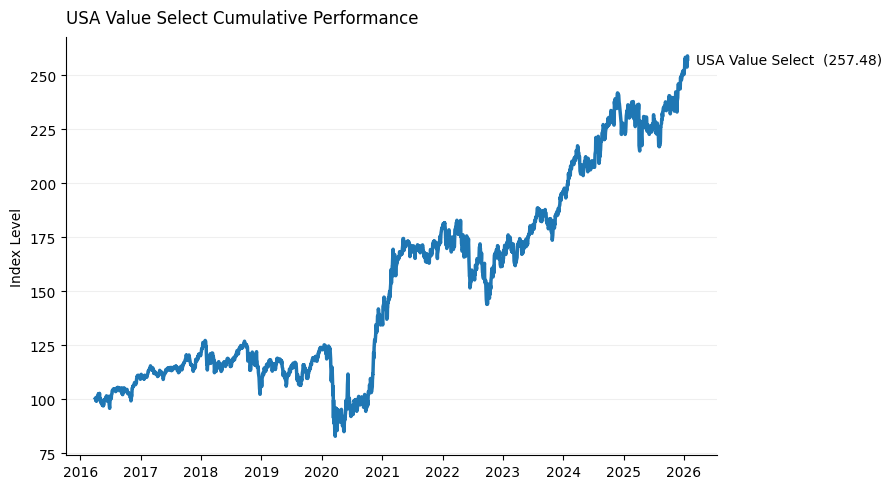

In [638]:
fig, ax = plt.subplots(figsize=(9, 5))

value_select_idx = index_daily_return_df['index_level']

# plot
ax.plot(value_select_idx.index, value_select_idx, linewidth=2.5, label="USA Value Select")

#title and ax labels
ax.set_title("USA Value Select Cumulative Performance", loc="left", pad=10)
ax.set_ylabel("Index Level")

# no top and right spines and grid lines
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis="y", linewidth=0.8, alpha=0.2)
ax.grid(False, axis="x")

# labels at the end of line (ill use for the next graphs)
def label_last(ax, series, text, dx=5, dy=0):
    x_last = series.index[-1]
    y_last = series.iloc[-1]
    ax.annotate(
        f"{text}  ({y_last:.2f})",
        xy=(x_last, y_last),
        xytext=(dx, dy),
        textcoords="offset points",
        va="center",
        fontsize=10
    )

label_last(ax, value_select_idx, "USA Value Select", dx=6, dy=0)

fig.tight_layout()
plt.show()

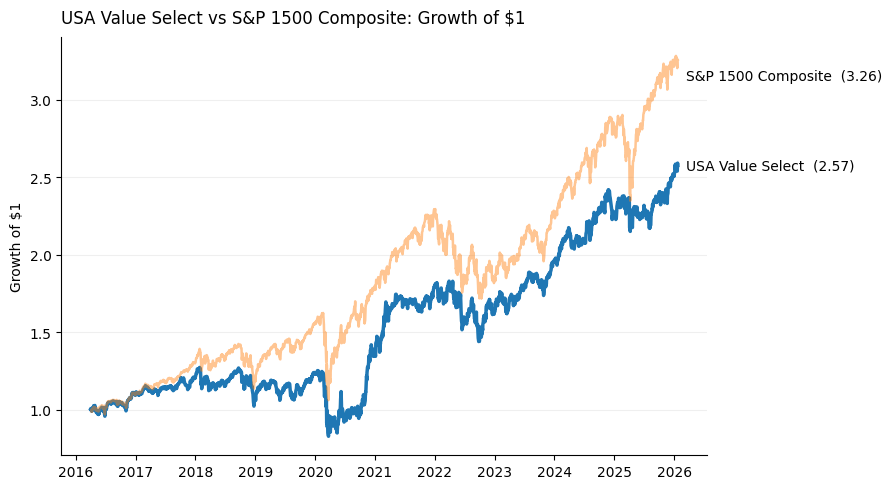

In [639]:
fig, ax = plt.subplots(figsize=(9, 5))

value_select_idx = index_daily_return_df['cum_return']
sp = sp_1500['cum_return']

# plots
ax.plot(value_select_idx.index, value_select_idx, linewidth=2.5, label="USA Value Select")
ax.plot(sp.index,  sp,  linewidth=1.8, alpha=0.45, label="S&P 1500 Composite")

# title and ax labels
ax.set_title("USA Value Select vs S&P 1500 Composite: Growth of $1", loc="left", pad=10)
ax.set_ylabel("Growth of $1")

# no top and right spines and grid lines
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis="y", linewidth=0.8, alpha=0.2)
ax.grid(False, axis="x")

# labels at the end of line
label_last(ax, value_select_idx, "USA Value Select", dx=6, dy=0)
label_last(ax, sp,  "S&P 1500 Composite", dx=6, dy=-12)

fig.tight_layout()
plt.show()


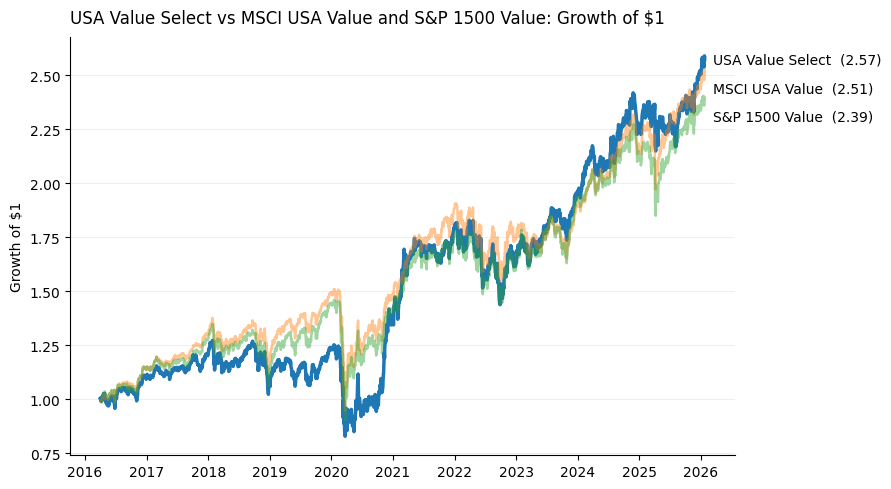

In [640]:
fig, ax = plt.subplots(figsize=(9, 5))

value_select_idx = index_daily_return_df['cum_return']
msci = msci_value_us['cum_return']
sp = sp1500_value['cum_return']

#plots
ax.plot(value_select_idx.index, value_select_idx, linewidth=2.5, label="USA Value Select")
ax.plot(msci.index,  msci,  linewidth=1.8, alpha=0.45, label="MSCI USA Value")
ax.plot(sp.index,  sp,  linewidth=1.8, alpha=0.45, label="S&P 1500 Value")

# title and axes
ax.set_title("USA Value Select vs MSCI USA Value and S&P 1500 Value: Growth of $1", loc="left", pad=10)
ax.set_ylabel("Growth of $1")

# no top and right spines and grid lines
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis="y", linewidth=0.8, alpha=0.2)
ax.grid(False, axis="x")

# labels at the end of line
label_last(ax, value_select_idx, "USA Value Select", dx=6, dy=0)
label_last(ax, msci,  "MSCI USA Value", dx=6, dy=-12)
label_last(ax, sp,  "S&P 1500 Value", dx=6, dy=-12)

fig.tight_layout()
plt.show()


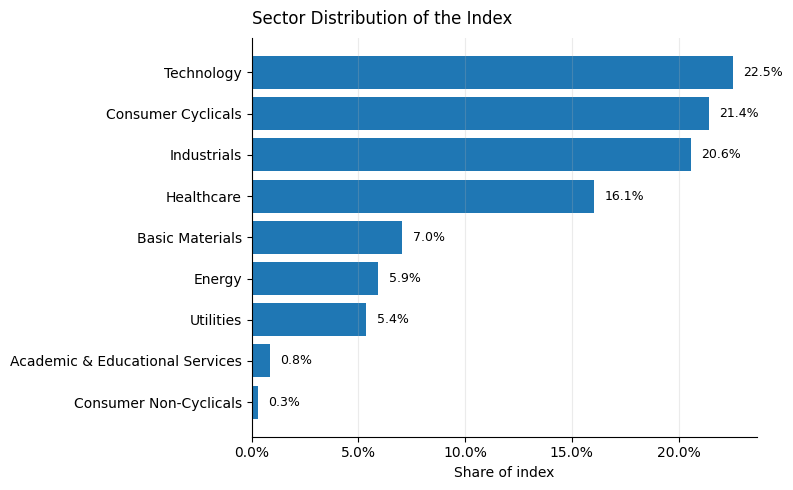

In [637]:
# current constituents distribution by sectors

# calendar year

sector_counts = selected_stocks['2025-10-01']['economic_sector'].value_counts()

sector_pct = (
    sector_counts
    .sort_values()                 # sort for horizontal bars
    .div(sector_counts.sum())
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8, 5))

#plot
ax.barh(sector_pct.index, sector_pct)

#title
ax.set_title("Sector Distribution of the Index", loc="left", pad=10)

# x axis formatting
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("Share of index")

ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, axis='x', alpha=0.25)
ax.grid(False, axis='y')

# percentage at the end of each bar
for i, v in enumerate(sector_pct):
    ax.text(
        v + 0.5,
        i,
        f"{v:.1f}%",
        va="center",
        fontsize=9
    )

fig.tight_layout()
plt.show()